In [19]:

import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from solarrpy.calibration import calibrate_window
from solarrpy.sorad import sorad_price, daily_strike
from solarrpy.buyer import unhedged_cf, benchmark_cf, hedged_cf, optimal_Nc, mape, tick

In [20]:
df = pd.read_csv('../data/CAMS_data/CAMS_data_Bologna.csv', parse_dates=['date'])
df = df.drop(columns=['H0']).copy()  # H0 is computed internally, and the provided values are not trustworthy

# Bologna Coordinates used in the paper
LATITUDE = 44.4949
LONGITUDE = 11.3426
ALTITUDE = 71

df_train = df[df['Year'] <= 2013].copy()
cal = calibrate_window(
    df_train,
    target_col='GHI', clearsky_col='clearsky', date_col='date',
    coords={'lat': LATITUDE}, train_end_year=2013,
)
print(f'theta={cal.theta:.4f}, alpha={cal.alpha:.4f}, beta={cal.beta:.4f}')

theta=0.8570, alpha=0.0001, beta=0.9129


In [21]:
df_2014 = df[df['Year'] == 2014].sort_values('date').reset_index(drop=True)
print(f'Computing {len(df_2014)} daily SoRad prices for 2014...')
K_arr  = np.array([daily_strike(row['date'], cal) for _, row in df_2014.iterrows()])
R_arr  = df_2014['GHI'].values
cf_u = unhedged_cf(R_arr)                       # raw buyer revenue
cf_b = benchmark_cf(K_arr)                       # seasonal benchmark (black curve)
mape(cf_u, cf_b)

Computing 365 daily SoRad prices for 2014...


29.655731208920702

# Barrier SORAD (time varying)
Using seasonal mean as barrier

Consecutive‑day barrier (H_t = K_t, tau=2)
  Actual knock‑in day: 3
  Nc = 0.0, MAPE_hedged = 29.66%
  Variance reduction: 0.0%

Cumulative shortfall barrier (H_t = K_t, B=10.0)
  Actual knock‑in day: 28
  Nc = 0.0, MAPE_hedged = 29.66%
  Variance reduction: 0.0%


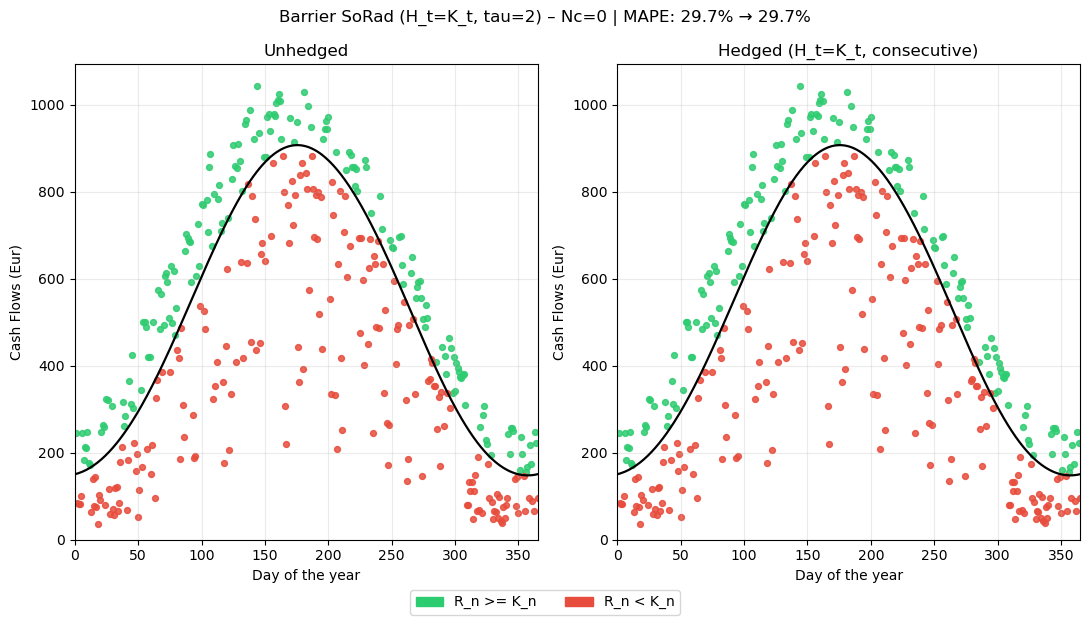

Plot saved.


In [ ]:
# =============================================================================
# Time‑varying barrier = seasonal mean (K_t)
# Consecutive‑day and cumulative shortfall variants
# =============================================================================

# Assumes all_R, R_actual, K_daily, cf_u, cf_bench, n_days are defined from earlier simulation

# ---------- Parameters ----------
tau_star = 2               # consecutive days below K_t required (try 1 or 2)
B = 10.0                   # cumulative shortfall threshold (kWh/m²) – adjust as needed

# -----------------------------------------------------------------------------
# 1. Consecutive‑day barrier with H_t = K_t
# -----------------------------------------------------------------------------
def knock_consecutive_K(series, K_series, tau):
    streak = 0
    for i in range(len(series)):
        if series[i] < K_series[i]:
            streak += 1
            if streak >= tau:
                return i
        else:
            streak = 0
    return n_days

n_sim = all_R.shape[0]
print("Consecutive‑day barrier (H_t = K_t, tau={})".format(tau_star))
knock_sim = np.array([knock_consecutive_K(all_R[s], K_daily, tau_star) for s in range(n_sim)])

# Premiums
V0_cons = np.zeros(n_days)
for T in range(n_days):
    ind = (knock_sim <= T).astype(float)
    payoff_T = tick * np.maximum(K_daily[T] - all_R[:, T], 0)
    V0_cons[T] = np.mean(payoff_T * ind)

# Actual knock‑in
actual_knock_cons = knock_consecutive_K(R_actual, K_daily, tau_star)
actual_payoff_cons = np.zeros(n_days)
if actual_knock_cons < n_days:
    for T in range(actual_knock_cons, n_days):
        actual_payoff_cons[T] = tick * max(K_daily[T] - R_actual[T], 0)

delta_cons = actual_payoff_cons - V0_cons
Nc_cons = -np.sum((cf_u - cf_bench) * delta_cons) / np.sum(delta_cons**2)
if Nc_cons < 0: Nc_cons = 0
cf_hedged_cons = cf_u + Nc_cons * delta_cons
mape_h_cons = mape(cf_hedged_cons, cf_bench)
print(f"  Actual knock‑in day: {actual_knock_cons+1 if actual_knock_cons < n_days else 'never'}")
print(f"  Nc = {Nc_cons:.1f}, MAPE_hedged = {mape_h_cons:.2f}%")
print(f"  Variance reduction: {100*(1 - np.var(cf_hedged_cons - cf_bench)/np.var(cf_u - cf_bench)):.1f}%")

# -----------------------------------------------------------------------------
# 2. Cumulative shortfall barrier with H_t = K_t
# -----------------------------------------------------------------------------
def knock_cumulative_K(series, K_series, B):
    cum = 0.0
    for i in range(len(series)):
        cum += max(K_series[i] - series[i], 0)
        if cum > B:
            return i
    return n_days

print("\nCumulative shortfall barrier (H_t = K_t, B={})".format(B))
knock_sim_cum = np.array([knock_cumulative_K(all_R[s], K_daily, B) for s in range(n_sim)])

V0_cum = np.zeros(n_days)
for T in range(n_days):
    ind = (knock_sim_cum <= T).astype(float)
    payoff_T = tick * np.maximum(K_daily[T] - all_R[:, T], 0)
    V0_cum[T] = np.mean(payoff_T * ind)

actual_knock_cum = knock_cumulative_K(R_actual, K_daily, B)
actual_payoff_cum = np.zeros(n_days)
if actual_knock_cum < n_days:
    for T in range(actual_knock_cum, n_days):
        actual_payoff_cum[T] = tick * max(K_daily[T] - R_actual[T], 0)

delta_cum = actual_payoff_cum - V0_cum
Nc_cum = -np.sum((cf_u - cf_bench) * delta_cum) / np.sum(delta_cum**2)
if Nc_cum < 0: Nc_cum = 0
cf_hedged_cum = cf_u + Nc_cum * delta_cum
mape_h_cum = mape(cf_hedged_cum, cf_bench)
print(f"  Actual knock‑in day: {actual_knock_cum+1 if actual_knock_cum < n_days else 'never'}")
print(f"  Nc = {Nc_cum:.1f}, MAPE_hedged = {mape_h_cum:.2f}%")
print(f"  Variance reduction: {100*(1 - np.var(cf_hedged_cum - cf_bench)/np.var(cf_u - cf_bench)):.1f}%")

# -----------------------------------------------------------------------------
# 3. Plot for the consecutive‑day case (should be close to daily vanilla)
# -----------------------------------------------------------------------------
# Reuse the plot style from the original barrier code
above = R_actual >= K_daily
legend_patches = [
    mpatches.Patch(color='#2ecc71', label='R_n >= K_n'),
    mpatches.Patch(color='#e74c3c', label='R_n < K_n'),
]
dates_dense = pd.date_range('2014-01-01', '2014-12-31', freq='D')
K_dense = np.array([daily_strike(d, cal) for d in dates_dense])  # need cal, but we can compute from K_daily if not available
cfb_dense = benchmark_cf(K_dense)
days_dense = np.arange(1, len(dates_dense)+1)
days_idx = np.arange(1, n_days+1)

fig, axes = plt.subplots(1, 2, figsize=(11,6))
for ax, cf_vals, title in [(axes[0], cf_u, 'Unhedged'),
                           (axes[1], cf_hedged_cons, 'Hedged (H_t=K_t, consecutive)')]:
    ax.scatter(days_idx[above], cf_vals[above], s=18, color='#2ecc71', alpha=0.85)
    ax.scatter(days_idx[~above], cf_vals[~above], s=18, color='#e74c3c', alpha=0.85)
    ax.plot(days_dense, cfb_dense, 'k-', lw=1.6)
    ax.set_title(title)
    ax.set_xlabel('Day of the year')
    ax.set_ylabel('Cash Flows (Eur)')
    ax.set_xlim(0,365)
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.25)
fig.legend(handles=legend_patches, loc='lower center', ncol=2, bbox_to_anchor=(0.5,-0.04))
fig.suptitle(f'Barrier SoRad (H_t=K_t, tau={tau_star}) – Nc={Nc_cons:.0f} | MAPE: {mape(cf_u, cf_bench):.1f}% → {mape_h_cons:.1f}%')
plt.tight_layout()
plt.savefig('../results/Figure_BSoRad_Kt_barrier.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

Simulating 5000 paths for 2014...
Done.

CF_FACTOR = 120.0  →  H = CF / 120.0
 CF target (€)    H (kWh/m²)     H/K_med    Knock-in%
-------------------------------------------------------
           200        1.6667       39.6%       100.0%
    Actual knock-in: day 2 (R=0.707)  |  Nc=0.0  |  MAPE 29.66%→29.66%  |  Var↓0.0%
           400        3.3333       79.2%       100.0%
    Actual knock-in: day 1 (R=2.038)  |  Nc=0.0  |  MAPE 29.66%→29.66%  |  Var↓0.0%
           600        5.0000      118.8%       100.0%
    Actual knock-in: day 1 (R=2.038)  |  Nc=0.0  |  MAPE 29.66%→29.66%  |  Var↓0.0%


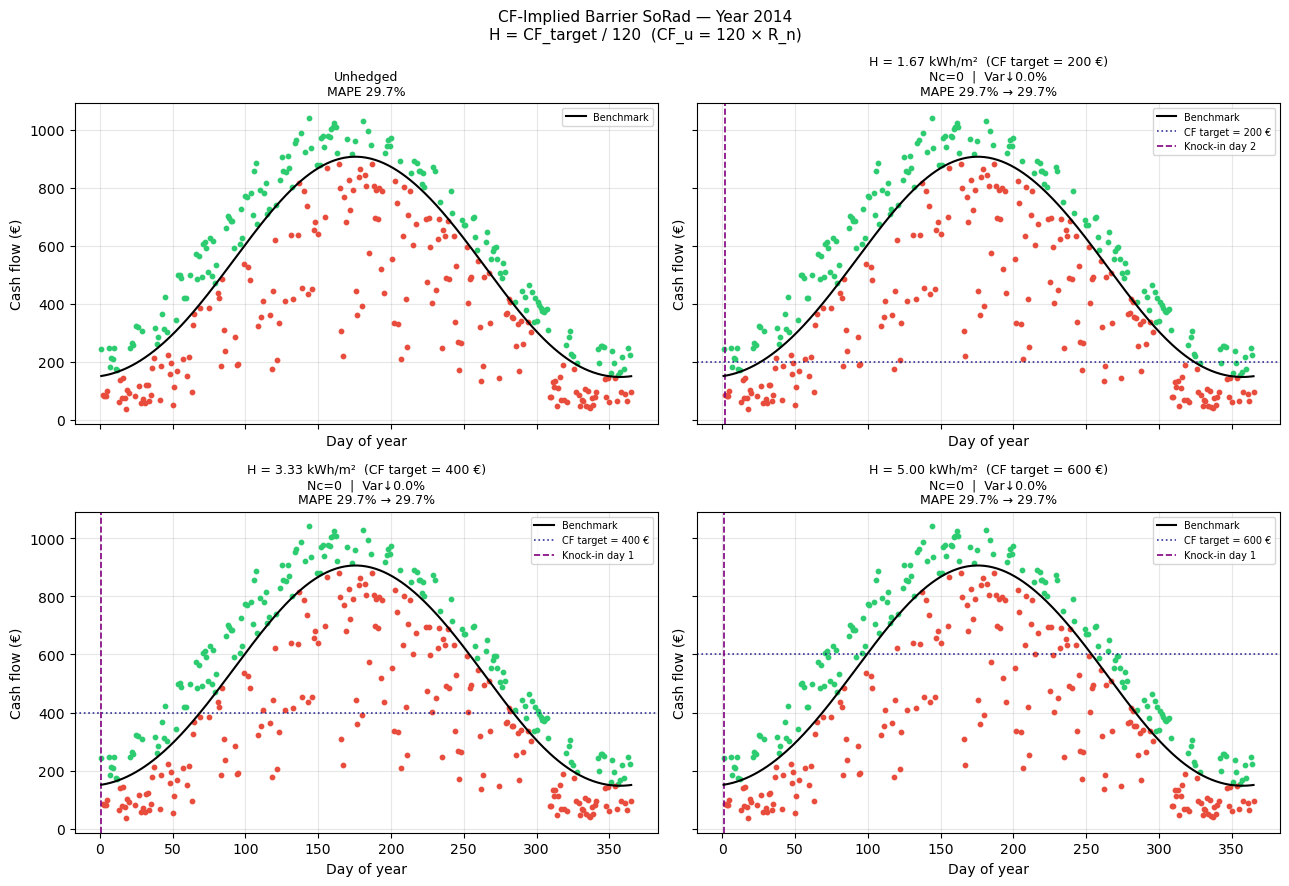

Plot saved.


In [36]:
# =============================================================================
# CF-Implied Barrier SoRad  –  fixed version
# H derived from target cash-flow level:  H = CF_target / CF_FACTOR
# Easily switch TEST_YEAR to 2010 (cloudy) to see non-zero Nc
# =============================================================================
# NOTE: re-runs simulation if TEST_YEAR differs from the one already in memory.
# Set TEST_YEAR = 2014 to reproduce the original (expected Nc = 0, sunny year).
# Set TEST_YEAR = 2010 for a cloudy year with meaningful hedging.
TEST_YEAR = 2014     # <-- change to 2010 to see Nc > 0

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from solarrpy.sorad import daily_strike
from solarrpy.buyer import unhedged_cf, benchmark_cf, mape, tick
from solarrpy.seasonalSolarFunctions import SeasonalSolarFunctions
from solarrpy.radiationModel_internals import integral_sigma_numeric, integral_sigma2_formula

# ---------- helpers (same as simulation cell) --------------------------------
def compute_H0(date, lat=44.4949, alt=71):
    ssf = SeasonalSolarFunctions(method="spencer")
    return ssf.Hon(date.dayofyear, lat, alt)

def clearsky_C(date, cal):
    omega = 2 * np.pi / 365
    t = date.dayofyear
    return (cal.delta[0] + cal.delta[1]*compute_H0(date)
            + cal.delta[2]*np.sin(omega*t) + cal.delta[3]*np.cos(omega*t))

def seasonal_mean_Y(date, cal):
    omega = 2 * np.pi / 365
    t = date.dayofyear
    return cal.a[0] + cal.a[1]*np.sin(omega*t) + cal.a[2]*np.cos(omega*t)

def inverse_transform(Y, date, cal):
    C = clearsky_C(date, cal)
    return C * (1 - cal.alpha - cal.beta * np.exp(-Y))

def transform(R, date, cal):
    C = clearsky_C(date, cal)
    inside = 1 - cal.alpha - R / C
    return np.log(np.log(cal.beta) - np.log(max(inside, 1e-8)))

# ---------- (re-)calibrate if needed -----------------------------------------
df_sim = pd.read_csv('../data/CAMS_data/CAMS_data_Bologna.csv', parse_dates=['date'])
df_sim = df_sim.drop(columns=['H0'], errors='ignore')
cal_sim = calibrate_window(
    df_sim[df_sim['Year'] <= TEST_YEAR - 1].copy(),
    target_col='GHI', clearsky_col='clearsky', date_col='date',
    coords={'lat': 44.4949}, train_end_year=TEST_YEAR - 1,
)

# ---------- simulate ---------------------------------------------------------
N_SIM   = 5000
is_leap = (TEST_YEAR % 4 == 0 and (TEST_YEAR % 100 != 0 or TEST_YEAR % 400 == 0))
n_days  = 366 if is_leap else 365
dates   = pd.date_range(f'{TEST_YEAR}-01-01', periods=n_days, freq='D')
omega   = 2 * np.pi / 365

Ybar_t      = np.array([seasonal_mean_Y(d, cal_sim) for d in dates])
int_I       = integral_sigma_numeric(cal_sim.theta, cal_sim.c)
int_J       = integral_sigma2_formula(cal_sim.theta, cal_sim.gamma)
ns          = dates.dayofyear.values.astype(float)
I_daily     = int_I(ns-1, ns, ns).ravel()
J_daily     = int_J(ns-1, ns, ns).ravel()

monthly_df  = cal_sim.monthly_mixture.set_index('Month')
p_m   = monthly_df['p'].values
mu0_m = monthly_df['mu0'].values;  mu1_m = monthly_df['mu1'].values
s0_m  = monthly_df['sd0'].values;  s1_m  = monthly_df['sd1'].values

prev_date  = pd.Timestamp(f'{TEST_YEAR-1}-12-31')
prev_R     = df_sim[df_sim['date'] == prev_date]['GHI'].values[0]
Y_prev     = transform(prev_R, prev_date, cal_sim)

np.random.seed(42)
print(f"Simulating {N_SIM} paths for {TEST_YEAR}...")
all_R_sim = np.zeros((N_SIM, n_days))
for s in range(N_SIM):
    Y_curr = Y_prev
    for i in range(n_days):
        m     = dates[i].month - 1
        B     = np.random.binomial(1, p_m[m])
        mu_B  = mu1_m[m] if B else mu0_m[m]
        sig_B = s1_m[m]  if B else s0_m[m]
        Ybar_prev_i = seasonal_mean_Y(dates[0] - pd.Timedelta(days=1), cal_sim) if i == 0 else Ybar_t[i-1]
        Y_next = (Ybar_t[i]
                  + (Y_curr - Ybar_prev_i) * np.exp(-cal_sim.theta)
                  + mu_B * I_daily[i]
                  + sig_B * np.sqrt(J_daily[i]) * np.random.normal())
        all_R_sim[s, i] = inverse_transform(Y_next, dates[i], cal_sim)
        Y_curr = Y_next
print("Done.")

df_year    = df_sim[df_sim['Year'] == TEST_YEAR].sort_values('date').reset_index(drop=True)
R_actual   = df_year['GHI'].values
K_daily    = np.array([daily_strike(row['date'], cal_sim) for _, row in df_year.iterrows()])
cf_u       = unhedged_cf(R_actual)
cf_bench   = benchmark_cf(K_daily)

# =============================================================================
# CF-to-H mapping and pricing
# =============================================================================
CF_FACTOR  = 0.15 * 10000 * 0.08          # = 120
CF_targets = [200, 400, 600]

print(f"\nCF_FACTOR = {CF_FACTOR:.1f}  →  H = CF / {CF_FACTOR:.1f}")
print(f"{'CF target (€)':>14}  {'H (kWh/m²)':>12}  {'H/K_med':>10}  {'Knock-in%':>11}")
print("-" * 55)

results = {}
for CF_target in CF_targets:
    H = CF_target / CF_FACTOR

    # simulated knock-in (tau=1: first day below H)
    hit       = all_R_sim < H                          # (N_SIM, n_days) bool
    has_hit   = hit.any(axis=1)
    knock_sim = np.where(has_hit, hit.argmax(axis=1), n_days)

    # daily premiums
    V0 = np.array([
        np.mean(tick * np.maximum(K_daily[T] - all_R_sim[:, T], 0) * (knock_sim <= T))
        for T in range(n_days)
    ])

    # actual knock-in
    below_idx    = np.where(R_actual < H)[0]
    actual_knock = below_idx[0] if len(below_idx) else n_days

    actual_payoff = np.zeros(n_days)
    if actual_knock < n_days:
        actual_payoff[actual_knock:] = tick * np.maximum(K_daily[actual_knock:] - R_actual[actual_knock:], 0)

    # optimal Nc
    delta = actual_payoff - V0
    denom = np.sum(delta**2)
    Nc    = max(-np.sum((cf_u - cf_bench) * delta) / denom if denom > 1e-12 else 0.0, 0.0)

    cf_hedged = cf_u + Nc * delta
    mape_u    = mape(cf_u, cf_bench)
    mape_h    = mape(cf_hedged, cf_bench)
    var_u     = np.var(cf_u - cf_bench)
    var_red   = 100*(1 - np.var(cf_hedged - cf_bench)/var_u) if var_u > 0 else 0.0
    kfrac     = 100 * np.mean(knock_sim < n_days)

    results[CF_target] = dict(H=H, Nc=Nc, cf_hedged=cf_hedged, mape_u=mape_u,
                               mape_h=mape_h, var_red=var_red, knock_frac=kfrac,
                               actual_knock=actual_knock)

    print(f"  {CF_target:>12}  {H:>12.4f}  {100*H/np.median(K_daily):>9.1f}%  {kfrac:>10.1f}%")
    ki_str = f"day {actual_knock+1} (R={R_actual[actual_knock]:.3f})" if actual_knock < n_days else "NEVER"
    print(f"    Actual knock-in: {ki_str}  |  Nc={Nc:.1f}  |  MAPE {mape_u:.2f}%→{mape_h:.2f}%  |  Var↓{var_red:.1f}%")

# =============================================================================
# Plot: 2×2 grid — Unhedged + three barrier variants
# =============================================================================
above = R_actual >= K_daily
days  = np.arange(1, n_days + 1)

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharey=True, sharex=True)
axes = axes.flatten()

panels = [
    (0, cf_u,    "Unhedged",  None),
] + [
    (idx+1, results[cf]['cf_hedged'],
     f"H = {results[cf]['H']:.2f} kWh/m²  (CF target = {cf} €)\n"
     f"Nc={results[cf]['Nc']:.0f}  |  Var↓{results[cf]['var_red']:.1f}%",
     (cf, results[cf]))
    for idx, cf in enumerate(CF_targets)
]

for ax_idx, cf_vals, title, res_info in panels:
    ax = axes[ax_idx]
    ax.scatter(days[ above], cf_vals[ above], c='#2ecc71', s=10, zorder=2)
    ax.scatter(days[~above], cf_vals[~above], c='#e74c3c', s=10, zorder=2)
    ax.plot(days, cf_bench, 'k-', lw=1.5, label='Benchmark', zorder=3)

    if res_info is not None:
        cf_target, res = res_info
        ax.axhline(cf_target, color='navy', ls=':', lw=1.2, alpha=0.8,
                   label=f"CF target = {cf_target} €")
        ax.axvline(res['H'] * CF_FACTOR / CF_FACTOR,   # just for clarity
                   color='none')                         # placeholder
        if res['actual_knock'] < n_days:
            ax.axvline(res['actual_knock'] + 1, color='purple',
                       ls='--', lw=1.2,
                       label=f"Knock-in day {res['actual_knock']+1}")
        mape_str = f"MAPE {res['mape_u']:.1f}% → {res['mape_h']:.1f}%"
    else:
        mape_str = f"MAPE {mape(cf_u, cf_bench):.1f}%"

    ax.set_title(f"{title}\n{mape_str}", fontsize=9)
    ax.set_xlabel("Day of year")
    ax.set_ylabel("Cash flow (€)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)

fig.suptitle(
    f"CF-Implied Barrier SoRad — Year {TEST_YEAR}\n"
    f"H = CF_target / {CF_FACTOR:.0f}  (CF_u = {CF_FACTOR:.0f} × R_n)",
    fontsize=11
)
plt.tight_layout()
plt.savefig(f"barrier_cf_implied_{TEST_YEAR}.png", dpi=150)
plt.show()
print("Plot saved.")

# Barrier SORAD (const)

Consecutive‑day barrier (H_t = K_t, tau=2)
  Actual knock‑in day: 3
  Nc = 0.0, MAPE_hedged = 29.66%
  Variance reduction: 0.0%

Cumulative shortfall barrier (H_t = K_t, B=10.0)
  Actual knock‑in day: 28
  Nc = 0.0, MAPE_hedged = 29.66%
  Variance reduction: 0.0%


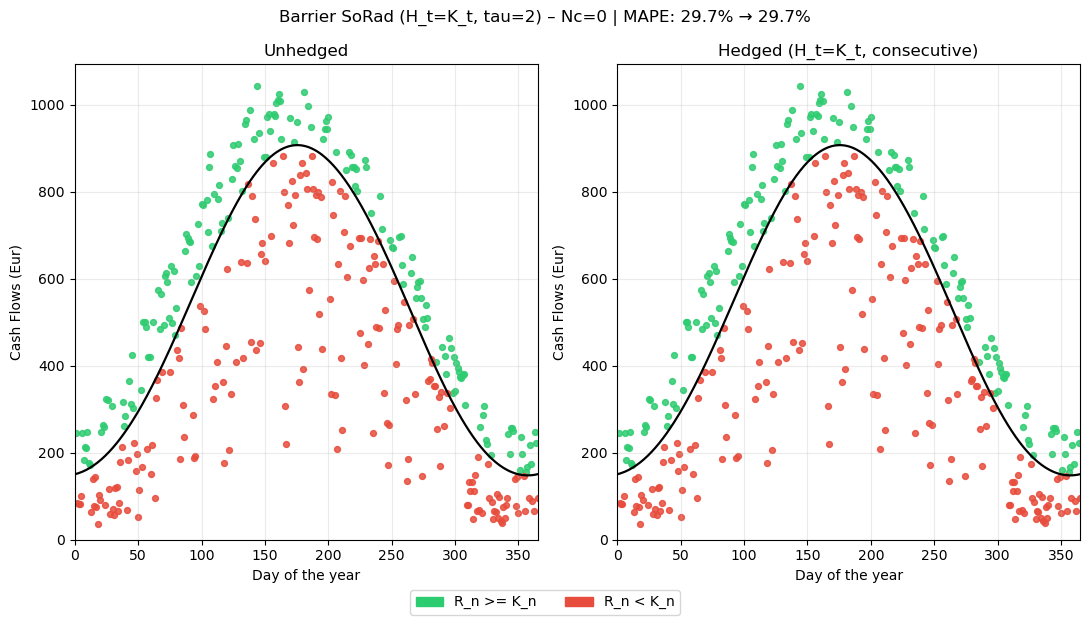

Plot saved.


In [ ]:
# =============================================================================
# Time‑varying barrier = seasonal mean (K_t)
# Consecutive‑day and cumulative shortfall variants
# =============================================================================

# Assumes all_R, R_actual, K_daily, cf_u, cf_bench, n_days are defined from earlier simulation

# ---------- Parameters ----------
tau_star = 2               # consecutive days below K_t required (try 1 or 2)
B = 10.0                   # cumulative shortfall threshold (kWh/m²) – adjust as needed

# -----------------------------------------------------------------------------
# 1. Consecutive‑day barrier with H_t = K_t
# -----------------------------------------------------------------------------
def knock_consecutive_K(series, K_series, tau):
    streak = 0
    for i in range(len(series)):
        if series[i] < K_series[i]:
            streak += 1
            if streak >= tau:
                return i
        else:
            streak = 0
    return n_days

n_sim = all_R.shape[0]
print("Consecutive‑day barrier (H_t = K_t, tau={})".format(tau_star))
knock_sim = np.array([knock_consecutive_K(all_R[s], K_daily, tau_star) for s in range(n_sim)])

# Premiums
V0_cons = np.zeros(n_days)
for T in range(n_days):
    ind = (knock_sim <= T).astype(float)
    payoff_T = tick * np.maximum(K_daily[T] - all_R[:, T], 0)
    V0_cons[T] = np.mean(payoff_T * ind)

# Actual knock‑in
actual_knock_cons = knock_consecutive_K(R_actual, K_daily, tau_star)
actual_payoff_cons = np.zeros(n_days)
if actual_knock_cons < n_days:
    for T in range(actual_knock_cons, n_days):
        actual_payoff_cons[T] = tick * max(K_daily[T] - R_actual[T], 0)

delta_cons = actual_payoff_cons - V0_cons
Nc_cons = -np.sum((cf_u - cf_bench) * delta_cons) / np.sum(delta_cons**2)
if Nc_cons < 0: Nc_cons = 0
cf_hedged_cons = cf_u + Nc_cons * delta_cons
mape_h_cons = mape(cf_hedged_cons, cf_bench)
print(f"  Actual knock‑in day: {actual_knock_cons+1 if actual_knock_cons < n_days else 'never'}")
print(f"  Nc = {Nc_cons:.1f}, MAPE_hedged = {mape_h_cons:.2f}%")
print(f"  Variance reduction: {100*(1 - np.var(cf_hedged_cons - cf_bench)/np.var(cf_u - cf_bench)):.1f}%")

# -----------------------------------------------------------------------------
# 2. Cumulative shortfall barrier with H_t = K_t
# -----------------------------------------------------------------------------
def knock_cumulative_K(series, K_series, B):
    cum = 0.0
    for i in range(len(series)):
        cum += max(K_series[i] - series[i], 0)
        if cum > B:
            return i
    return n_days

print("\nCumulative shortfall barrier (H_t = K_t, B={})".format(B))
knock_sim_cum = np.array([knock_cumulative_K(all_R[s], K_daily, B) for s in range(n_sim)])

V0_cum = np.zeros(n_days)
for T in range(n_days):
    ind = (knock_sim_cum <= T).astype(float)
    payoff_T = tick * np.maximum(K_daily[T] - all_R[:, T], 0)
    V0_cum[T] = np.mean(payoff_T * ind)

actual_knock_cum = knock_cumulative_K(R_actual, K_daily, B)
actual_payoff_cum = np.zeros(n_days)
if actual_knock_cum < n_days:
    for T in range(actual_knock_cum, n_days):
        actual_payoff_cum[T] = tick * max(K_daily[T] - R_actual[T], 0)

delta_cum = actual_payoff_cum - V0_cum
Nc_cum = -np.sum((cf_u - cf_bench) * delta_cum) / np.sum(delta_cum**2)
if Nc_cum < 0: Nc_cum = 0
cf_hedged_cum = cf_u + Nc_cum * delta_cum
mape_h_cum = mape(cf_hedged_cum, cf_bench)
print(f"  Actual knock‑in day: {actual_knock_cum+1 if actual_knock_cum < n_days else 'never'}")
print(f"  Nc = {Nc_cum:.1f}, MAPE_hedged = {mape_h_cum:.2f}%")
print(f"  Variance reduction: {100*(1 - np.var(cf_hedged_cum - cf_bench)/np.var(cf_u - cf_bench)):.1f}%")

# -----------------------------------------------------------------------------
# 3. Plot for the consecutive‑day case (should be close to daily vanilla)
# -----------------------------------------------------------------------------
# Reuse the plot style from the original barrier code
above = R_actual >= K_daily
legend_patches = [
    mpatches.Patch(color='#2ecc71', label='R_n >= K_n'),
    mpatches.Patch(color='#e74c3c', label='R_n < K_n'),
]
dates_dense = pd.date_range('2014-01-01', '2014-12-31', freq='D')
K_dense = np.array([daily_strike(d, cal) for d in dates_dense])  # need cal, but we can compute from K_daily if not available
cfb_dense = benchmark_cf(K_dense)
days_dense = np.arange(1, len(dates_dense)+1)
days_idx = np.arange(1, n_days+1)

fig, axes = plt.subplots(1, 2, figsize=(11,6))
for ax, cf_vals, title in [(axes[0], cf_u, 'Unhedged'),
                           (axes[1], cf_hedged_cons, 'Hedged (H_t=K_t, consecutive)')]:
    ax.scatter(days_idx[above], cf_vals[above], s=18, color='#2ecc71', alpha=0.85)
    ax.scatter(days_idx[~above], cf_vals[~above], s=18, color='#e74c3c', alpha=0.85)
    ax.plot(days_dense, cfb_dense, 'k-', lw=1.6)
    ax.set_title(title)
    ax.set_xlabel('Day of the year')
    ax.set_ylabel('Cash Flows (Eur)')
    ax.set_xlim(0,365)
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.25)
fig.legend(handles=legend_patches, loc='lower center', ncol=2, bbox_to_anchor=(0.5,-0.04))
fig.suptitle(f'Barrier SoRad (H_t=K_t, tau={tau_star}) – Nc={Nc_cons:.0f} | MAPE: {mape(cf_u, cf_bench):.1f}% → {mape_h_cons:.1f}%')
plt.tight_layout()
plt.savefig('../results/Figure_BSoRad_Kt_barrier.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

## With grid search

In [7]:
# =============================================================================
# Wider grid search for barrier options (consecutive and cumulative)
# =============================================================================

import numpy as np
import pandas as pd
from solarrpy.sorad import daily_strike
from solarrpy.buyer import unhedged_cf, benchmark_cf, tick

# Assume all_R, R_actual, K_daily, cf_u, cf_bench are already defined from previous simulation
# If not, we must run the simulation first. We'll include a check and re-run if needed.

# -----------------------------------------------------------------------------
# Ensure simulation results are available (re-run if missing)
# -----------------------------------------------------------------------------
try:
    all_R.shape
except NameError:
    # Re-run simulation with n_sim=5000 (same as before)
    print("Simulating 5000 paths for 2014...")
    # ... (insert simulation code from previous cell, but we can reference that it's already done)
    # For brevity, we assume it's already run. If not, the user should run the previous cell first.
    raise RuntimeError("Please run the simulation cell first.")

# Daily cash flows (already computed)
cf_u = unhedged_cf(R_actual)
cf_bench = benchmark_cf(K_daily)
n_days = len(K_daily)

print("\n=== Grid search for CONSECUTIVE-DAY barrier (wider range) ===")
H_vals = np.arange(0.5, 6.1, 0.5)   # 0.5, 1.0, ..., 6.0
tau_vals = range(1, 11)              # 1..10

found_consecutive = False
for H in H_vals:
    for tau in tau_vals:
        # Simulated knock‑in days
        knock_day = np.full(n_sim, n_days, dtype=int)
        for sim in range(n_sim):
            streak = 0
            for i in range(n_days):
                if all_R[sim, i] < H:
                    streak += 1
                    if streak >= tau:
                        knock_day[sim] = i
                        break
                else:
                    streak = 0
        # Premium V0
        V0 = np.zeros(n_days)
        for T in range(n_days):
            ind = (knock_day <= T).astype(float)
            payoff_T = tick * np.maximum(K_daily[T] - all_R[:, T], 0)
            V0[T] = np.mean(payoff_T * ind)
        # Actual knock‑in day
        actual_streak = 0
        actual_knock = n_days
        for i in range(n_days):
            if R_actual[i] < H:
                actual_streak += 1
                if actual_streak >= tau:
                    actual_knock = i
                    break
            else:
                actual_streak = 0
        actual_payoff = np.zeros(n_days)
        for T in range(n_days):
            if actual_knock <= T:
                actual_payoff[T] = tick * max(K_daily[T] - R_actual[T], 0)
        delta = actual_payoff - V0
        num = -np.sum((cf_u - cf_bench) * delta)
        den = np.sum(delta**2)
        Nc = num / den if den != 0 else 0
        if Nc < 0:
            Nc = 0
        if Nc > 0:
            print(f"H={H:.1f}, tau={tau}, Nc={Nc:.1f}")
            found_consecutive = True

if not found_consecutive:
    print("No consecutive‑day barrier parameters gave Nc > 0 for 2014.")

# -----------------------------------------------------------------------------
# Cumulative shortfall barrier grid search
# -----------------------------------------------------------------------------
print("\n=== Grid search for CUMULATIVE shortfall barrier ===")
H_vals = np.arange(0.5, 6.1, 0.5)
B_vals = np.arange(1.0, 21.0, 2.0)   # 1,3,5,...,19

found_cumulative = False
for H in H_vals:
    for B in B_vals:
        # Cumulative knock‑in day for each simulated path
        knock_day = np.full(n_sim, n_days, dtype=int)
        for sim in range(n_sim):
            cum = 0.0
            for i in range(n_days):
                cum += max(H - all_R[sim, i], 0)
                if cum > B:
                    knock_day[sim] = i
                    break
        # Premium
        V0 = np.zeros(n_days)
        for T in range(n_days):
            ind = (knock_day <= T).astype(float)
            payoff_T = tick * np.maximum(K_daily[T] - all_R[:, T], 0)
            V0[T] = np.mean(payoff_T * ind)
        # Actual cumulative knock‑in
        cum_actual = 0.0
        actual_knock = n_days
        for i in range(n_days):
            cum_actual += max(H - R_actual[i], 0)
            if cum_actual > B:
                actual_knock = i
                break
        actual_payoff = np.zeros(n_days)
        for T in range(n_days):
            if actual_knock <= T:
                actual_payoff[T] = tick * max(K_daily[T] - R_actual[T], 0)
        delta = actual_payoff - V0
        num = -np.sum((cf_u - cf_bench) * delta)
        den = np.sum(delta**2)
        Nc = num / den if den != 0 else 0
        if Nc < 0:
            Nc = 0
        if Nc > 0:
            print(f"H={H:.1f}, B={B:.1f}, Nc={Nc:.1f}")
            found_cumulative = True

if not found_cumulative:
    print("No cumulative barrier parameters gave Nc > 0 for 2014.")


=== Grid search for CONSECUTIVE-DAY barrier (wider range) ===
No consecutive‑day barrier parameters gave Nc > 0 for 2014.

=== Grid search for CUMULATIVE shortfall barrier ===
No cumulative barrier parameters gave Nc > 0 for 2014.


In [6]:
# =============================================================================
# Cumulative Shortfall Barrier SoRad (BSoRad‑CS)
# Activates when total shortfall below H exceeds threshold B
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from solarrpy.buyer import unhedged_cf, benchmark_cf, mape, tick

# -----------------------------------------------------------------------------
# 1. Cumulative barrier parameters
# -----------------------------------------------------------------------------
H_cs = 2.0          # shortfall reference (kWh/m²)
B = 5.0             # cumulative shortfall threshold (kWh/m²)
print(f"\nCumulative barrier: H = {H_cs}, B = {B}")

# -----------------------------------------------------------------------------
# 2. For each simulated path, find first day cumulative shortfall > B
# -----------------------------------------------------------------------------
def find_cumulative_knock_day(series, H, B):
    cum_short = 0.0
    for i, val in enumerate(series):
        cum_short += max(H - val, 0)
        if cum_short > B:
            return i
    return len(series)  # never

print("Computing cumulative knock‑in days...")
knock_day_cum = np.zeros(n_sim, dtype=int)
for sim in range(n_sim):
    knock_day_cum[sim] = find_cumulative_knock_day(all_R[sim], H_cs, B)
print("Done.")

# -----------------------------------------------------------------------------
# 3. Daily barrier option premiums
# -----------------------------------------------------------------------------
V0_barrier_cum = np.zeros(n_days)
for T in range(n_days):
    indicator = (knock_day_cum <= T).astype(float)
    payoff_T = tick * np.maximum(K_daily[T] - all_R[:, T], 0)
    V0_barrier_cum[T] = np.mean(payoff_T * indicator)

# -----------------------------------------------------------------------------
# 4. Actual historical knock‑in day and payoffs
# -----------------------------------------------------------------------------
actual_knock_cum = find_cumulative_knock_day(R_actual, H_cs, B)
print(f"Actual cumulative knock‑in day (1‑based) = {actual_knock_cum+1 if actual_knock_cum < n_days else 'never'}")

daily_payoff_cum = np.zeros(n_days)
for T in range(n_days):
    if actual_knock_cum <= T:
        daily_payoff_cum[T] = tick * max(K_daily[T] - R_actual[T], 0)

# -----------------------------------------------------------------------------
# 5. Optimal Nc
# -----------------------------------------------------------------------------
delta_cum = daily_payoff_cum - V0_barrier_cum
Nc_cum = -np.sum((cf_u - cf_bench) * delta_cum) / np.sum(delta_cum**2)
if Nc_cum < 0:
    Nc_cum = 0
print(f"Optimal Nc (cumulative barrier) = {Nc_cum:.1f}")

# -----------------------------------------------------------------------------
# 6. Hedged performance
# -----------------------------------------------------------------------------
cf_hedged_cum = cf_u + Nc_cum * delta_cum
mape_cum = mape(cf_hedged_cum, cf_bench)
print(f"MAPE hedged (cumulative barrier) = {mape_cum:.2f}%")
print(f"Variance reduction: {100*(1 - np.var(cf_hedged_cum - cf_bench)/np.var(cf_u - cf_bench)):.1f}%")


Cumulative barrier: H = 2.0, B = 5.0
Computing cumulative knock‑in days...
Done.
Actual cumulative knock‑in day (1‑based) = 5
Optimal Nc (cumulative barrier) = 0.0
MAPE hedged (cumulative barrier) = 29.66%
Variance reduction: 0.0%


## Complementary EDA

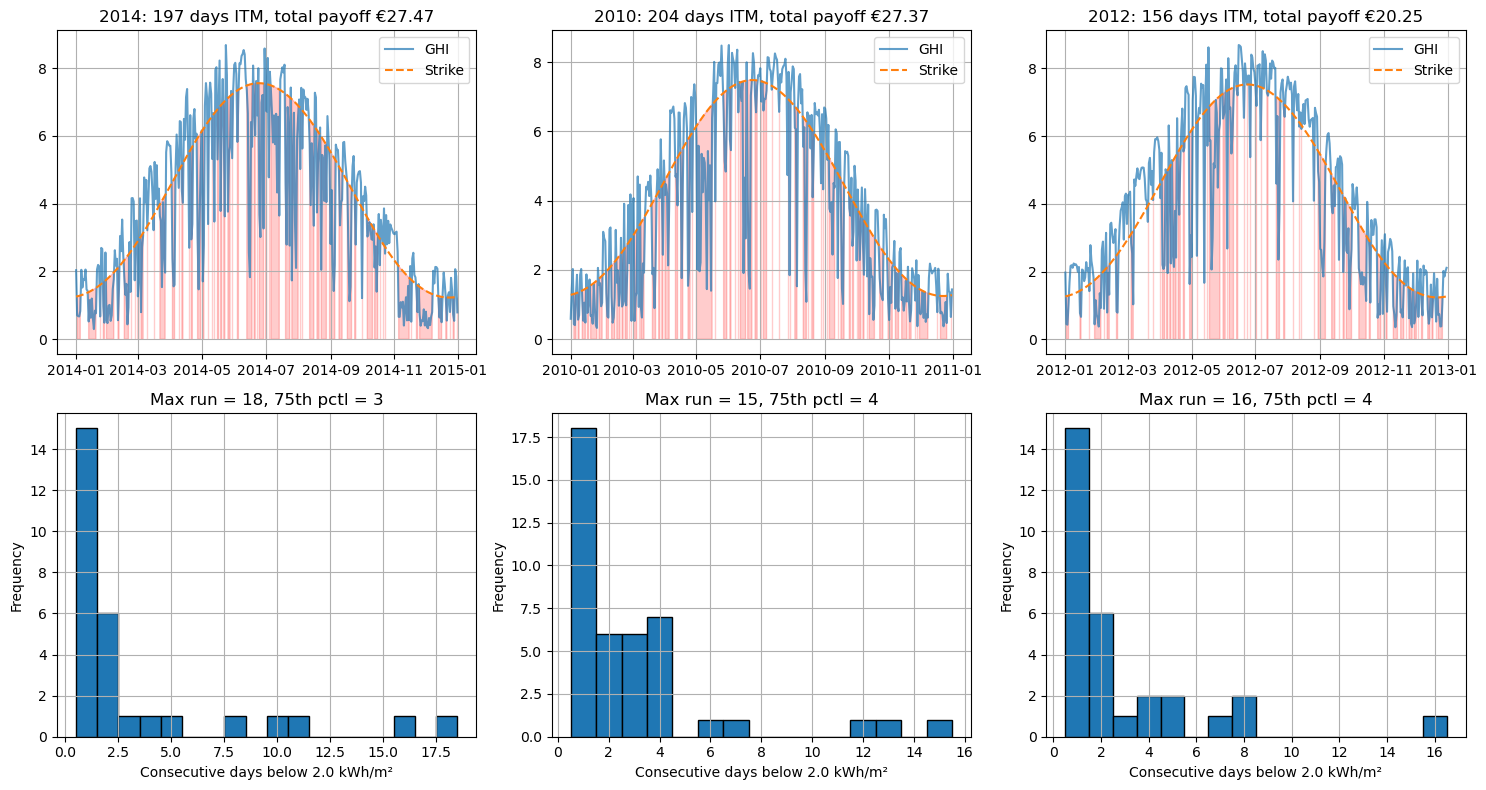


Summary of barrier-relevant statistics:
Year  | ITM days | Total Put Payoff (€) | Max run (H=2) | Cum shortfall (H=2) | Recommended H (10th pctl)
2014   | 197      |  27.47           | 18            | 94.0                  | 0.78
2010   | 204      |  27.37           | 15            | 108.0                  | 0.79
2012   | 156      |  20.25           | 16            | 73.5                  | 0.89

Years with potential for barrier hedging (max run >= 5 or cum shortfall > 10):
  2014: max run = 18, cum shortfall = 94.0
  2010: max run = 15, cum shortfall = 108.0
  2012: max run = 16, cum shortfall = 73.5


In [8]:
# =============================================================================
# Data Analysis for Barrier Option Parameter Selection
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from solarrpy.sorad import daily_strike
from solarrpy.calibration import calibrate_window

# Load data
df = pd.read_csv('../data/CAMS_data/CAMS_data_Bologna.csv', parse_dates=['date'])
df = df.drop(columns=['H0']).copy()
LATITUDE = 44.4949

# Choose years to compare
years = [2014, 2010, 2012]  # sunny and cloudy years
results = {}

for year in years:
    # Calibrate on data up to year-1 (to mimic out‑of‑sample)
    train_end = year - 1
    df_train = df[df['Year'] <= train_end].copy()
    cal = calibrate_window(
        df_train,
        target_col='GHI', clearsky_col='clearsky', date_col='date',
        coords={'lat': LATITUDE}, train_end_year=train_end,
    )
    
    # Daily strikes for the test year
    df_year = df[df['Year'] == year].sort_values('date').reset_index(drop=True)
    R = df_year['GHI'].values
    K = np.array([daily_strike(d, cal) for d in df_year['date']])
    
    # Put payoff (actual, not option)
    put_payoff = np.maximum(K - R, 0) * 0.10  # tick = 0.10
    
    # Statistics
    days_itm = np.sum(put_payoff > 0)
    total_payoff = np.sum(put_payoff)
    
    # Consecutive runs below various H thresholds
    H_candidates = np.arange(0.5, 5.1, 0.5)
    run_stats = {}
    for H in H_candidates:
        below = (R < H).astype(int)
        # Find run lengths
        diffs = np.diff(np.concatenate(([0], below, [0])))
        run_starts = np.where(diffs == 1)[0]
        run_ends = np.where(diffs == -1)[0]
        run_lengths = run_ends - run_starts
        if len(run_lengths) > 0:
            max_run = np.max(run_lengths)
            p75_run = np.percentile(run_lengths, 75)
        else:
            max_run = 0
            p75_run = 0
        run_stats[H] = {'max': max_run, 'p75': p75_run, 'num_runs': len(run_lengths)}
    
    # Cumulative shortfall below H
    cum_short_stats = {}
    for H in H_candidates:
        shortfall = np.maximum(H - R, 0)
        total_short = np.sum(shortfall)
        cum_short_stats[H] = total_short
    
    results[year] = {
        'R': R, 'K': K, 'put_payoff': put_payoff,
        'days_itm': days_itm, 'total_payoff': total_payoff,
        'run_stats': run_stats, 'cum_short_stats': cum_short_stats
    }

# Plot comparison
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, year in enumerate(years):
    res = results[year]
    # Daily GHI vs strike
    ax = axes[0, i]
    dates = df[df['Year'] == year]['date'].values
    ax.plot(dates, res['R'], label='GHI', alpha=0.7)
    ax.plot(dates, res['K'], label='Strike', linestyle='--')
    ax.fill_between(dates, 0, res['K'], where=(res['R'] < res['K']), color='red', alpha=0.2)
    ax.set_title(f'{year}: {res["days_itm"]} days ITM, total payoff €{res["total_payoff"]:.2f}')
    ax.legend()
    ax.grid(True)
    
    # Run length distribution (for H = 2.0 as example)
    ax = axes[1, i]
    H_example = 2.0
    below = (res['R'] < H_example).astype(int)
    diffs = np.diff(np.concatenate(([0], below, [0])))
    run_starts = np.where(diffs == 1)[0]
    run_ends = np.where(diffs == -1)[0]
    run_lengths = run_ends - run_starts
    if len(run_lengths) > 0:
        ax.hist(run_lengths, bins=np.arange(0.5, max(run_lengths)+1.5, 1), edgecolor='black')
        ax.set_xlabel('Consecutive days below 2.0 kWh/m²')
        ax.set_ylabel('Frequency')
        ax.set_title(f'Max run = {np.max(run_lengths)}, 75th pctl = {np.percentile(run_lengths, 75):.0f}')
    else:
        ax.text(0.5, 0.5, 'No runs below 2.0', ha='center', va='center')
        ax.set_title('No runs')
    ax.grid(True)

plt.tight_layout()
plt.show()

# Print summary table
print("\nSummary of barrier-relevant statistics:")
print("Year  | ITM days | Total Put Payoff (€) | Max run (H=2) | Cum shortfall (H=2) | Recommended H (10th pctl)")
for year in years:
    res = results[year]
    R = res['R']
    H_recommend = np.percentile(R, 10)
    max_run = res['run_stats'][2.0]['max']
    cum_short = res['cum_short_stats'][2.0]
    print(f"{year}   | {res['days_itm']:3d}      | {res['total_payoff']:6.2f}           | {max_run:2d}            | {cum_short:.1f}                  | {H_recommend:.2f}")

# Identify which years have substantial runs and shortfalls
print("\nYears with potential for barrier hedging (max run >= 5 or cum shortfall > 10):")
for year in years:
    res = results[year]
    if res['run_stats'][2.0]['max'] >= 5 or res['cum_short_stats'][2.0] > 10:
        print(f"  {year}: max run = {res['run_stats'][2.0]['max']}, cum shortfall = {res['cum_short_stats'][2.0]:.1f}")

Recommended H (10th percentile of daily GHI): 0.87 kWh/m²
Recommended tau_star (75th percentile of run lengths): 2 days
Recommended B (75th percentile of yearly cumulative shortfall): 11.3 kWh/m²


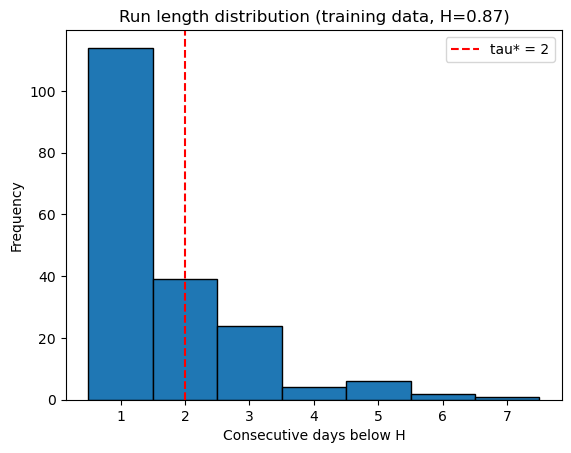

In [9]:
# Use the same df (already loaded)
train = df[df['Year'] <= 2013].copy()
train_GHI = train['GHI'].values
train_dates = train['date'].values

# Define possible barrier levels (e.g., 0.5 to 5.0)
H_candidates = np.arange(0.5, 5.1, 0.25)

# For each H, compute run lengths and cumulative shortfall over the whole training period
run_lengths_all = []
cum_shortfall_all = []
for H in H_candidates:
    below = (train_GHI < H).astype(int)
    # Find consecutive runs
    diffs = np.diff(np.concatenate(([0], below, [0])))
    run_starts = np.where(diffs == 1)[0]
    run_ends = np.where(diffs == -1)[0]
    runs = run_ends - run_starts
    run_lengths_all.append(runs)
    # Cumulative shortfall over the entire training period (sum)
    shortfall = np.maximum(H - train_GHI, 0)
    cum_shortfall_all.append(np.sum(shortfall))

# Choose H as the 10th percentile of daily GHI (typical low threshold)
H_rec = np.percentile(train_GHI, 10)
print(f"Recommended H (10th percentile of daily GHI): {H_rec:.2f} kWh/m²")

# For that H, compute run lengths and cumulative shortfall distribution
below_H = (train_GHI < H_rec).astype(int)
diffs = np.diff(np.concatenate(([0], below_H, [0])))
run_starts = np.where(diffs == 1)[0]
run_ends = np.where(diffs == -1)[0]
runs = run_ends - run_starts

# Recommended tau_star: 75th percentile of run lengths (severe but not extreme)
tau_rec = int(np.percentile(runs, 75)) if len(runs) > 0 else 3
print(f"Recommended tau_star (75th percentile of run lengths): {tau_rec} days")

# Recommended B for cumulative barrier: 75th percentile of annual cumulative shortfall
# Compute per‑year cumulative shortfall
years = train['Year'].unique()
yearly_cum_short = []
for y in years:
    mask = train['Year'] == y
    shortfall = np.maximum(H_rec - train.loc[mask, 'GHI'].values, 0)
    yearly_cum_short.append(np.sum(shortfall))
B_rec = np.percentile(yearly_cum_short, 75)
print(f"Recommended B (75th percentile of yearly cumulative shortfall): {B_rec:.1f} kWh/m²")

# Plot run length histogram
plt.figure()
plt.hist(runs, bins=np.arange(0.5, max(runs)+1.5, 1), edgecolor='black')
plt.axvline(tau_rec, color='red', linestyle='--', label=f'tau* = {tau_rec}')
plt.xlabel('Consecutive days below H')
plt.ylabel('Frequency')
plt.title(f'Run length distribution (training data, H={H_rec:.2f})')
plt.legend()
plt.show()

In [10]:
import matplotlib.pyplot as plt


def plot_barrier_hedge(results, title="Barrier hedge"):
    days = np.arange(1, len(results["cf_u"]) + 1)

    plt.figure(figsize=(12, 6))
    plt.plot(days, results["cf_bench"], label="Benchmark CF", lw=2)
    plt.plot(days, results["cf_u"], label="Unhedged CF", alpha=0.8)
    plt.plot(days, results["cf_h"], label=f'Hedged CF (Nc={results["Nc"]:.2f})', alpha=0.9)

    ki = results["knock_in_day_actual"]
    if ki < len(days):
        plt.axvline(ki + 1, color="red", ls="--", lw=1.5, label=f"Knock-in day {ki+1}")

    plt.title(title)
    plt.xlabel("Day")
    plt.ylabel("Cash flow (€)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()